### Exploratory Data Analysis
##### Roles to Explore:

In [17]:
# Importing Libraries - 
import ast
import pandas as pd
import seaborn as sns
from datasets import load_dataset
import matplotlib.pyplot as plt

# Loading Data
dataset = load_dataset('lukebarousse/data_jobs')
df = dataset['train'].to_pandas()

# Data Cleanup
df['job_posted_date'] = pd.to_datetime(df['job_posted_date'])
df['job_skills'] = df['job_skills'].apply(lambda x: ast.literal_eval(x) if pd.notna(x) else x)

##### Filter for US Data Analyst Role

In [18]:
df_DA_US = df[(df['job_country'] == 'United States') & (df['job_title_short'] == 'Data Analyst')]

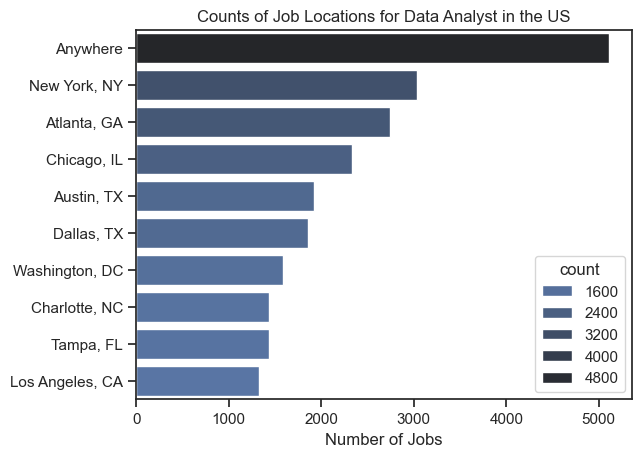

In [45]:
# Job Location (Top 10)
df_location_plot = df_DA_US['job_location'].value_counts().head(10).to_frame()

sns.set_theme(style='ticks')
sns.barplot(data=df_location_plot, x="count", y="job_location", hue='count', palette='dark:b_r')
plt.title("Counts of Job Locations for Data Analyst in the US")
plt.xlabel("Number of Jobs")
plt.ylabel("")
plt.show()

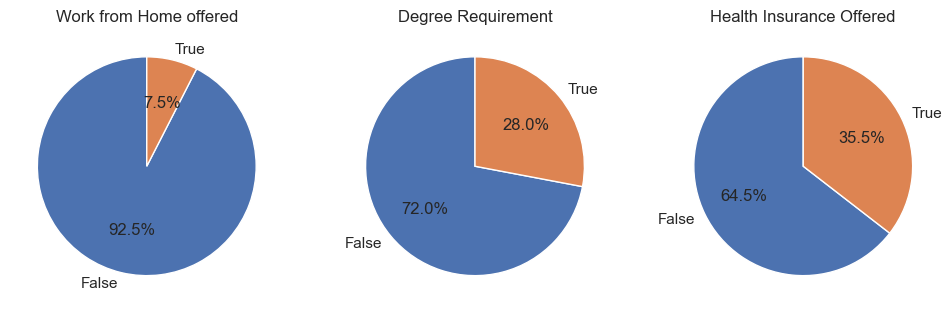

In [46]:
# Benefit Analysis of Data Jobs -> Work from Home offered, Degree Requirement & Health Insurance Offered

dict_column = {
    'job_work_from_home': "Work from Home offered",
    'job_no_degree_mention': "Degree Requirement",
    'job_health_insurance': "Health Insurance Offered",
}

fig, ax = plt.subplots(1, 3)
fig.set_size_inches((12, 5))

for i, (column, title) in enumerate(dict_column.items()):
    ax[i].pie(df_DA_US[column].value_counts(), labels=['False', 'True'], autopct="%1.1f%%", startangle=90)
    ax[i].set_title(title)

plt.show()

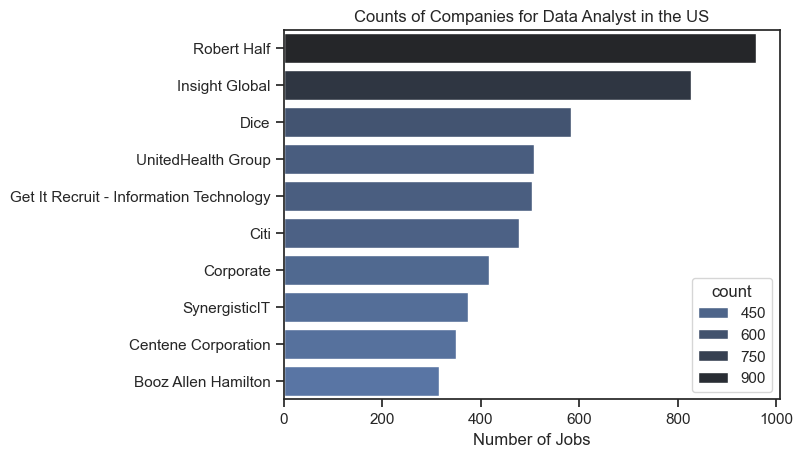

In [47]:
# Companies

df_location_plot = df_DA_US['company_name'].value_counts().head(10).to_frame()

sns.set_theme(style='ticks')
sns.barplot(data=df_location_plot, x="count", y="company_name", hue='count', palette='dark:b_r')
plt.title("Counts of Companies for Data Analyst in the US")
plt.xlabel("Number of Jobs")
plt.ylabel("")
plt.show()